In [1]:
# In this code, we generate the data locally so that we may speed up the processing of data in the learning process. 

import tensorflow as tf
from dataGenNew import rand_En, rand_costheta, rand_phi, full_measure 
import numpy as np
import time
import matplotlib.pyplot as plt
import os


# Define some initial parameters for the gneration process

res = 32
n_coeff=4
noise = 0.01

filenameTrain = "dataset_32by32_train_more"
filenameTest = "dataset_32by32_test_more"

In [2]:
# Determine number of training examples

total = 16000

test = 0.15*total
train = 0.85*total 

normal_test = 0.50*test
special_test = 0.50*test

special_train = 0.20*train 
normal_train = 0.80*train


# Let's check that our training example looks good

In [3]:
# Let's generate one example 

a1=rand_En(n_coeff,res)
a2=np.tanh(5*np.arccos(rand_costheta(n_coeff,res)))
a2True = a2*np.pi
a3=rand_phi(n_coeff,res)
            
if a2[0,0]>np.pi/2: #make sure the first pixel has nz>0
    a2=np.pi-a2
        
X =full_measure(a1,a2,a3,res,noise)

# Plot the distributions of the unitary maps


'''
fig,  ax = plt.subplots(1,3,figsize=(20,20))


ax[0].imshow(a1)
ax[1].imshow(a2)
ax[2].imshow(a3)


ax[0].set_title('a1')
ax[1].set_title('a2')
ax[2].set_title('a3')

fig.colorbar(plt.imshow(a2))


'''


plt.savefig('sample_unitary.png')



<Figure size 432x288 with 0 Axes>

In [8]:
np.pi - a2True*np.random.uniform(0,0.1)

array([[2.90654728, 2.90654729, 2.9065473 , ..., 2.90654727, 2.90654728,
        2.90654728],
       [2.90654731, 2.90654733, 2.90654735, ..., 2.90654729, 2.9065473 ,
        2.9065473 ],
       [2.90654735, 2.90654738, 2.90654742, ..., 2.90654731, 2.90654731,
        2.9065473 ],
       ...,
       [2.90654727, 2.90654749, 2.90654854, ..., 2.90654784, 2.90654826,
        2.9065481 ],
       [2.90654728, 2.90654755, 2.90654903, ..., 2.90654774, 2.90654801,
        2.90654786],
       [2.90654729, 2.90654759, 2.90654931, ..., 2.90654761, 2.90654777,
        2.90654767]])

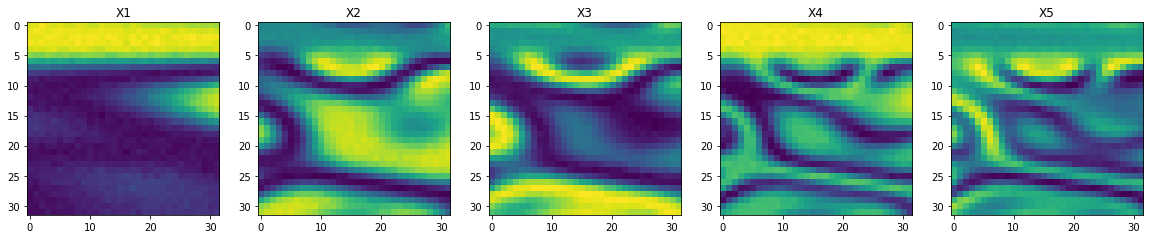

In [9]:
# Plot the distributions of the polametric measuremenets

# Plot the distributions of the unitary maps

fig,  ax = plt.subplots(1,5,figsize=(20,20))


ax[0].imshow(X[:,:,0])
ax[1].imshow(X[:,:,1])
ax[2].imshow(X[:,:,2])
ax[3].imshow(X[:,:,3])
ax[4].imshow(X[:,:,4])


ax[0].set_title('X1')
ax[1].set_title('X2')
ax[2].set_title('X3')
ax[3].set_title('X4')
ax[4].set_title('X5')

plt.savefig('sample_pol_measure.png')


# Create Training Dataset

In [9]:
import pickle
import random

X = np.empty((int(train), res, res, 5))
y = np.empty((int(train), res, res, 3))

# First, generate normal examples
    
for ii in range(int(normal_train)):
    
    a1=rand_En(n_coeff,res)
    a2=np.arccos(rand_costheta(n_coeff,res))
    a3=rand_phi(n_coeff,res)
            
    if a2[0,0]>np.pi/2: #make sure the first pixel has nz>0
        a2=np.pi-a2
        
    y[ii,:,:,0] = a1
    y[ii,:,:,1] = a2
    y[ii,:,:,2] = a3
        
    X[ii] = full_measure(a1,a2,a3,res,noise)
    
    
    if ii % 100 == 0:
        print('Training data: ', ii, '/',normal_train)
print("Finished generating normal training examples!!")


# Generate special examples

print("Now generating special examples")

for ii in range(int(normal_train), int(normal_train)+int(special_train)):
    
    # we toss a coin to decide around which pole along the Bloch sphere we'd like to sample
    func = None
    coin = random.randint(0,1)
    if (coin == 0):
        func = lambda x: 0.001*x
        print("Zero")
    else:
        if (coin == 1):
            func = lambda x: np.tanh(5*x)*np.pi
            print("Pi")
    
    a1=rand_En(n_coeff,res)
    a2=func(np.arccos(rand_costheta(n_coeff,res)))
    a3=rand_phi(n_coeff,res)
            
    y[ii,:,:,0] = a1
    y[ii,:,:,1] = a2
    y[ii,:,:,2] = a3
        
    X[ii] = full_measure(a1,a2,a3,res,noise)
    
    
    if ii % 100 == 0:
        print('Training data: ', ii-normal_train, '/', special_train)
print("Finished generating special training examples!!")
    
# Dump everything 
    
with open(filenameTrain + '.pkl', 'wb') as f:
    pickle.dump([X, y], f)
        

Training data:  0 / 10880.0
Training data:  100 / 10880.0
Training data:  200 / 10880.0
Training data:  300 / 10880.0
Training data:  400 / 10880.0
Training data:  500 / 10880.0
Training data:  600 / 10880.0
Training data:  700 / 10880.0
Training data:  800 / 10880.0
Training data:  900 / 10880.0
Training data:  1000 / 10880.0
Training data:  1100 / 10880.0
Training data:  1200 / 10880.0
Training data:  1300 / 10880.0
Training data:  1400 / 10880.0
Training data:  1500 / 10880.0
Training data:  1600 / 10880.0
Training data:  1700 / 10880.0
Training data:  1800 / 10880.0
Training data:  1900 / 10880.0
Training data:  2000 / 10880.0
Training data:  2100 / 10880.0
Training data:  2200 / 10880.0
Training data:  2300 / 10880.0
Training data:  2400 / 10880.0
Training data:  2500 / 10880.0
Training data:  2600 / 10880.0
Training data:  2700 / 10880.0
Training data:  2800 / 10880.0
Training data:  2900 / 10880.0
Training data:  3000 / 10880.0
Training data:  3100 / 10880.0
Training data:  3200

Zero
Zero
Zero
Zero
Zero
Pi
Zero
Zero
Pi
Pi
Zero
Zero
Pi
Zero
Pi
Zero
Training data:  1120.0 / 2720.0
Zero
Pi
Zero
Pi
Pi
Zero
Pi
Pi
Pi
Zero
Zero
Pi
Zero
Pi
Zero
Pi
Zero
Zero
Pi
Zero
Pi
Pi
Pi
Pi
Pi
Zero
Pi
Pi
Zero
Zero
Zero
Pi
Pi
Zero
Zero
Zero
Pi
Pi
Pi
Zero
Pi
Pi
Zero
Pi
Pi
Zero
Pi
Zero
Pi
Zero
Zero
Zero
Zero
Pi
Zero
Zero
Zero
Pi
Zero
Zero
Zero
Pi
Pi
Pi
Pi
Pi
Pi
Zero
Zero
Pi
Zero
Pi
Pi
Pi
Zero
Pi
Zero
Zero
Pi
Zero
Zero
Pi
Zero
Pi
Pi
Zero
Zero
Zero
Zero
Zero
Pi
Zero
Pi
Zero
Zero
Zero
Pi
Zero
Pi
Zero
Training data:  1220.0 / 2720.0
Zero
Pi
Pi
Zero
Zero
Pi
Zero
Zero
Zero
Pi
Zero
Zero
Zero
Zero
Zero
Zero
Pi
Pi
Pi
Zero
Zero
Pi
Zero
Pi
Zero
Pi
Zero
Pi
Zero
Pi
Pi
Zero
Zero
Zero
Zero
Pi
Zero
Pi
Pi
Pi
Zero
Pi
Zero
Zero
Pi
Zero
Zero
Zero
Pi
Pi
Zero
Pi
Zero
Pi
Zero
Zero
Pi
Zero
Zero
Zero
Zero
Zero
Zero
Pi
Pi
Zero
Pi
Zero
Zero
Pi
Pi
Zero
Zero
Pi
Pi
Zero
Zero
Pi
Pi
Pi
Zero
Pi
Zero
Zero
Pi
Pi
Zero
Pi
Pi
Pi
Pi
Zero
Pi
Zero
Zero
Zero
Zero
Zero
Zero
Pi
Training data:  1320.0 / 2720.0
Zero
Pi
Pi
Pi
Pi
Z

# Generate Test Dataset

In [10]:
import pickle
import random

X = np.empty((int(test), res, res, 5))
y = np.empty((int(test), res, res, 3))

# First, generate normal examples
    
for ii in range(int(normal_test)):
    
    a1=rand_En(n_coeff,res)
    a2=np.arccos(rand_costheta(n_coeff,res))
    a3=rand_phi(n_coeff,res)
            
    if a2[0,0]>np.pi/2: #make sure the first pixel has nz>0
        a2=np.pi-a2
        
    y[ii,:,:,0] = a1
    y[ii,:,:,1] = a2
    y[ii,:,:,2] = a3
        
    X[ii] = full_measure(a1,a2,a3,res,noise)
    
    
    if ii % 100 == 0:
        print('Training data: ', ii, '/',normal_test)
print("Finished generating noraml training examples!!")


# Generate special examples

print("Now generating special examples")

for ii in range(int(normal_test), int(normal_test)+int(special_test)):
    
    # we toss a coin to decide around which pole along the Bloch sphere we'd like to sample
    func = None
    coin = random.randint(0,1)
    if (coin == 0):
        func = lambda x: 0.001*x
        print("Zero")
    else:
        if (coin == 1):
            func = lambda x: np.tanh(5*x)
            print("Pi")
    
    a1=rand_En(n_coeff,res)
    a2=func(np.arccos(rand_costheta(n_coeff,res)))
    a3=rand_phi(n_coeff,res)
            
    y[ii,:,:,0] = a1
    y[ii,:,:,1] = a2
    y[ii,:,:,2] = a3
        
    X[ii] = full_measure(a1,a2,a3,res,noise)
    
    
    if ii % 100 == 0:
        print('Training data: ', ii-normal_test, '/', special_test)
print("Finished generating special training examples!!")
    
# Dump everything 
    
with open(filenameTest + '.pkl', 'wb') as f:
    pickle.dump([X, y], f)
        

Training data:  0 / 1200.0
Training data:  100 / 1200.0
Training data:  200 / 1200.0
Training data:  300 / 1200.0
Training data:  400 / 1200.0
Training data:  500 / 1200.0
Training data:  600 / 1200.0
Training data:  700 / 1200.0
Training data:  800 / 1200.0
Training data:  900 / 1200.0
Training data:  1000 / 1200.0
Training data:  1100 / 1200.0
Finished generating noraml training examples!!
Now generating special examples
Zero
Training data:  0.0 / 1200.0
Pi
Zero
Pi
Zero
Zero
Zero
Zero
Pi
Zero
Pi
Pi
Zero
Zero
Zero
Pi
Pi
Pi
Pi
Pi
Pi
Pi
Zero
Pi
Zero
Pi
Pi
Zero
Zero
Zero
Zero
Zero
Zero
Zero
Zero
Zero
Zero
Pi
Pi
Pi
Zero
Zero
Zero
Pi
Zero
Pi
Zero
Pi
Pi
Pi
Zero
Zero
Pi
Pi
Pi
Zero
Zero
Pi
Pi
Pi
Zero
Pi
Zero
Pi
Pi
Zero
Zero
Zero
Pi
Zero
Pi
Zero
Pi
Pi
Zero
Zero
Pi
Pi
Pi
Pi
Zero
Zero
Zero
Zero
Pi
Pi
Zero
Pi
Zero
Zero
Zero
Pi
Pi
Pi
Zero
Pi
Pi
Zero
Zero
Zero
Pi
Training data:  100.0 / 1200.0
Pi
Pi
Pi
Pi
Zero
Zero
Zero
Pi
Pi
Zero
Pi
Zero
Pi
Pi
Pi
Zero
Zero
Zero
Pi
Pi
Zero
Zero
Pi
Zero
Zero
Zero
Pi